# Lahore CH₄ Source Attribution
## Multi-month TROPOMI anomaly + ERA5 wind back-trajectory + Gaussian plume inversion

**Goal:** Identify *where* elevated methane comes from — mimicking GHGSat-style source geolocation at the resolution publicly available data allows.

**Pipeline:**
1. 5-month TROPOMI stack (Oct 2025 – Feb 2026) → persistent hotspot cells
2. ERA5 10-m wind → monthly mean back-trajectory per hotspot
3. Gaussian plume inversion → source emission rates (kg/hr, tonne CH₄/yr)
4. OSM source inventory (landfills, industrial zones, wastewater plants)
5. NASA EMIT global plume catalog — filter to Lahore bounding box
6. Ranked source GeoJSON export for the HUDI frontend

> **Note on resolution:** TROPOMI native ~5.5 km. GHGSat achieves 25 m via a
> commercial WGS instrument not publicly accessible. NASA EMIT (ISS, ~60 m) is
> the closest open equivalent; its plume catalog is checked below.

### 0 · Setup

In [1]:
import calendar, json, math, pathlib, urllib.request, warnings
warnings.filterwarnings("ignore")

import ee
import geemap
import geopandas as gpd
import numpy as np
import pandas as pd
import requests
from shapely.geometry import Point, LineString

EE_PROJECT = "1035330553052"
try:
    ee.Initialize(project=EE_PROJECT)
except Exception:
    ee.Authenticate(auth_mode="localhost")
    ee.Initialize(project=EE_PROJECT)

HERE = pathlib.Path(".").resolve()
print("Working dir:", HERE)

Working dir: /Users/ahmed/Desktop/Senior Spring 26/SPROJ - Dr Tahir/SPROJ/notebooks/methane


### 1 · Parameters

In [2]:
UC_SHP = "../../data/Lahore UCs/Lahore UC.shp"

# 5-month window for robust statistics
MONTHS = [(2025, 10), (2025, 11), (2025, 12), (2026, 1), (2026, 2)]

CH4_BAND       = "CH4_column_volume_mixing_ratio_dry_air_bias_corrected"
EXPORT_SCALE_M = 250

GLOBAL_BG_PPB  = 1920.0   # approximate 2025 global CH4 background
T_K            = 298.0
P_PA           = 101325.0
M_CH4          = 16.04

# Pasquill-Gifford D (neutral, low wind)
PG_Y = 0.1
PG_Z = 0.05

P_MODERATE = 0.70
P_HIGH     = 0.85
P_EXTREME  = 0.95

TRANSPORT_HOURS = [1, 2, 3, 6]

print("Months:", [f"{y}-{m:02d}" for y, m in MONTHS])

Months: ['2025-10', '2025-11', '2025-12', '2026-01', '2026-02']


### 2 · Load Lahore Boundary

In [3]:
gdf_boundary = gpd.read_file(UC_SHP).to_crs(4326)
gdf_boundary["geometry"] = gdf_boundary["geometry"].buffer(0)

lahore_ee = geemap.gdf_to_ee(gdf_boundary).geometry()
bbox = gdf_boundary.total_bounds
S, W, N, E = bbox[1], bbox[0], bbox[3], bbox[2]
CRS_M = "EPSG:32643"

print(f"Loaded {len(gdf_boundary)} union council polygons")
print(f"Bounds: {bbox.round(4)}")

Loaded 171 union council polygons
Bounds: [74.0033 31.2503 74.6421 31.7386]


### 3 · Build 5-Month TROPOMI Stack

Each month is a median composite. Stacking 5 months isolates *persistent* spatial patterns from transient pollution episodes.

In [4]:
def month_median_ch4(year, month):
    last_day = calendar.monthrange(year, month)[1]
    s = f"{year:04d}-{month:02d}-01"
    e = f"{year:04d}-{month:02d}-{last_day:02d}"
    return (ee.ImageCollection("COPERNICUS/S5P/OFFL/L3_CH4")
              .filterBounds(lahore_ee).filterDate(s, e)
              .select([CH4_BAND]).median()
              .rename(f"CH4_{year}_{month:02d}").clip(lahore_ee))

monthly_images = [month_median_ch4(y, m) for y, m in MONTHS]
stack = ee.Image.cat(monthly_images)

stack_mean = stack.reduce(ee.Reducer.mean()).rename("ch4_mean_ppb")
stack_std  = stack.reduce(ee.Reducer.stdDev()).rename("ch4_std_ppb")
stack_min  = stack.reduce(ee.Reducer.min()).rename("ch4_min_ppb")
stack_max  = stack.reduce(ee.Reducer.max()).rename("ch4_max_ppb")

median_val = stack_mean.reduceRegion(
    reducer=ee.Reducer.median(), geometry=lahore_ee,
    scale=5500, maxPixels=1e6).getInfo().get("ch4_mean_ppb")

anomaly = stack_mean.subtract(GLOBAL_BG_PPB).rename("ch4_anomaly_ppb")

persistence = ee.Image.cat([
    monthly_images[i].gt(median_val).rename(f"above_{i}")
    for i in range(len(MONTHS))
]).reduce(ee.Reducer.sum()).rename("persistence_months")

composite = (ee.Image.pixelLonLat()
    .addBands(stack_mean).addBands(anomaly)
    .addBands(stack_std).addBands(stack_min)
    .addBands(stack_max).addBands(persistence))

print("Exporting stack composite...")
pts = composite.sample(region=lahore_ee, scale=EXPORT_SCALE_M, geometries=True, seed=1)
geemap.ee_export_vector(pts, filename=str(HERE / "ch4_stack_250m.geojson"))
print(f"[OK] 5-month median: {median_val:.1f} ppb | anomaly vs {GLOBAL_BG_PPB:.0f} ppb background")

Exporting stack composite...
Generating URL ...
Please wait ...
Data downloaded to /Users/ahmed/Desktop/Senior Spring 26/SPROJ - Dr Tahir/SPROJ/notebooks/methane/ch4_stack_250m.geojson
[OK] 5-month median: 1974.1 ppb | anomaly vs 1920 ppb background


### 4 · Hotspot Classification

In [5]:
gdf_stack = gpd.read_file(HERE / "ch4_stack_250m.geojson")
gdf_stack = gdf_stack[gdf_stack["ch4_mean_ppb"].notna()].copy()
print(f"Valid grid cells: {len(gdf_stack):,}")

anom = gdf_stack["ch4_anomaly_ppb"]
thr = {"moderate": anom.quantile(P_MODERATE),
       "high":     anom.quantile(P_HIGH),
       "extreme":  anom.quantile(P_EXTREME)}
print(f"Anomaly p70={thr['moderate']:.1f}  p85={thr['high']:.1f}  p95={thr['extreme']:.1f} ppb")

def classify(v):
    if v >= thr["extreme"]:  return 3
    if v >= thr["high"]:     return 2
    if v >= thr["moderate"]: return 1
    return 0

gdf_stack["hotspot_level"] = gdf_stack["ch4_anomaly_ppb"].apply(classify)
gdf_stack["hotspot_label"] = gdf_stack["hotspot_level"].map(
    {0:"background", 1:"moderate", 2:"high", 3:"extreme"})
gdf_stack["is_persistent"] = (
    (gdf_stack["hotspot_level"] >= 2) &
    (gdf_stack["persistence_months"] >= 3))

print(gdf_stack["hotspot_label"].value_counts().to_string())
print(f"Persistent hotspots: {gdf_stack['is_persistent'].sum()}")

Valid grid cells: 33,678
Anomaly p70=61.7  p85=67.7  p95=71.3 ppb
hotspot_label
background    23567
moderate       5044
high           3364
extreme        1703
Persistent hotspots: 5067


### 5 · ERA5 Wind Field (5-Month Mean)

In [6]:
def month_mean_wind(year, month):
    last_day = calendar.monthrange(year, month)[1]
    return (ee.ImageCollection("ECMWF/ERA5_LAND/HOURLY")
              .filterDate(f"{year:04d}-{month:02d}-01",
                          f"{year:04d}-{month:02d}-{last_day:02d}")
              .select(["u_component_of_wind_10m","v_component_of_wind_10m"])
              .mean())

wind_mean = ee.ImageCollection(
    [month_mean_wind(y, m) for y, m in MONTHS]).mean()

wind_pts = (ee.Image.pixelLonLat().addBands(wind_mean)
            .sample(region=lahore_ee, scale=5500, geometries=True, seed=1))
geemap.ee_export_vector(wind_pts, filename=str(HERE / "wind_field.geojson"))

gdf_wind = gpd.read_file(HERE / "wind_field.geojson").dropna()
gdf_wind["wind_speed_ms"] = np.sqrt(
    gdf_wind["u_component_of_wind_10m"]**2 +
    gdf_wind["v_component_of_wind_10m"]**2)
gdf_wind["wind_dir_from_deg"] = (
    np.degrees(np.arctan2(-gdf_wind["u_component_of_wind_10m"],
                           -gdf_wind["v_component_of_wind_10m"])) + 360) % 360

u_city = gdf_wind["u_component_of_wind_10m"].mean()
v_city = gdf_wind["v_component_of_wind_10m"].mean()
speed_city = np.sqrt(u_city**2 + v_city**2)
dir_from   = (np.degrees(np.arctan2(-u_city, -v_city)) + 360) % 360

print(f"City-mean wind: u={u_city:.2f} v={v_city:.2f} speed={speed_city:.2f} m/s")
print(f"  From: {dir_from:.0f} deg")
print(gdf_wind[["wind_speed_ms","wind_dir_from_deg"]].describe().round(2))

Generating URL ...
Please wait ...
Data downloaded to /Users/ahmed/Desktop/Senior Spring 26/SPROJ - Dr Tahir/SPROJ/notebooks/methane/wind_field.geojson
City-mean wind: u=0.78 v=-0.34 speed=0.85 m/s
  From: 294 deg
       wind_speed_ms  wind_dir_from_deg
count          67.00              67.00
mean            0.86             293.09
std             0.13               6.95
min             0.66             279.48
25%             0.73             288.29
50%             0.84             292.80
75%             0.95             298.55
max             1.13             304.40


### 6 · Wind Back-Trajectory Source Attribution

For each persistent hotspot, trace back along the local ERA5 wind vector at 1, 2, 3, and 6 hour transport times to locate candidate source regions.

In [7]:
hotspots = gdf_stack[gdf_stack["is_persistent"]].copy()
hotspots_m = hotspots.to_crs(CRS_M)
gdf_wind_m  = gdf_wind.to_crs(CRS_M)

source_rows = []
trajectory_rows = []

for _, row in hotspots_m.iterrows():
    cx = row.geometry.centroid.x
    cy = row.geometry.centroid.y
    dists = gdf_wind_m.geometry.distance(row.geometry.centroid)
    w = gdf_wind_m.iloc[dists.argmin()]
    u = w["u_component_of_wind_10m"]
    v = w["v_component_of_wind_10m"]

    for t_hr in TRANSPORT_HOURS:
        t_sec = t_hr * 3600
        sx = cx - u * t_sec
        sy = cy - v * t_sec
        source_rows.append({
            "geometry": Point(sx, sy),
            "receptor_anomaly_ppb": row["ch4_anomaly_ppb"],
            "persistence_months": row["persistence_months"],
            "hotspot_label": row["hotspot_label"],
            "transport_hr": t_hr,
        })
        trajectory_rows.append({
            "geometry": LineString([(sx, sy), (cx, cy)]),
            "transport_hr": t_hr,
            "anomaly_ppb": row["ch4_anomaly_ppb"],
        })

gdf_sources      = gpd.GeoDataFrame(source_rows, crs=CRS_M).to_crs(4326)
gdf_trajectories = gpd.GeoDataFrame(trajectory_rows, crs=CRS_M).to_crs(4326)
print(f"Source candidates: {len(gdf_sources)}  |  Trajectories: {len(gdf_trajectories)}")

Source candidates: 20268  |  Trajectories: 20268


### 7 · Gaussian Plume Emission Rate Inversion

$$Q \\approx C \\cdot u \\cdot \\pi \\cdot \\sigma_y \\cdot \\sigma_z$$

C = column anomaly converted to surface concentration; Pasquill–Gifford D stability class (neutral, low wind).

In [8]:
def ppb_to_ug_m3(ppb):
    mol_frac = ppb * 1e-9
    n_air = P_PA / (8.314 * T_K)
    return n_air * mol_frac * M_CH4 * 1e6

dist_m  = max(speed_city * 3 * 3600, 5500.0)
sigma_y = PG_Y * dist_m
sigma_z = PG_Z * dist_m

hotspots_m2 = hotspots_m.copy()
hotspots_m2["C_ug_m3"] = hotspots_m2["ch4_anomaly_ppb"].apply(ppb_to_ug_m3)
hotspots_m2["Q_mg_s"]  = hotspots_m2["C_ug_m3"] * speed_city * math.pi * sigma_y * sigma_z / 1e3
hotspots_m2["Q_kg_hr"] = hotspots_m2["Q_mg_s"] * 3.6e-6
hotspots_m2["Q_t_yr"]  = hotspots_m2["Q_kg_hr"] * 8760e-3
hotspots_wgs = hotspots_m2.to_crs(4326)

print(f"Downwind dist: {dist_m/1000:.1f} km  sigma_y={sigma_y:.0f} m  sigma_z={sigma_z:.0f} m")
print(hotspots_wgs[["ch4_anomaly_ppb","persistence_months","Q_t_yr"]]
      .sort_values("Q_t_yr",ascending=False).head(10).round(2).to_string(index=False))

Downwind dist: 9.2 km  sigma_y=921 m  sigma_z=460 m
 ch4_anomaly_ppb  persistence_months  Q_t_yr
           75.68                   5    1.78
           75.68                   5    1.78
           75.68                   5    1.78
           75.68                   5    1.78
           75.68                   5    1.78
           75.68                   5    1.78
           75.68                   5    1.78
           75.68                   5    1.78
           75.68                   5    1.78
           75.68                   5    1.78


### 8 · OSM Source Inventory + Known Sources

In [9]:
OVERPASS = "https://overpass-api.de/api/interpreter"
BBOX_OV  = f"{S:.4f},{W:.4f},{N:.4f},{E:.4f}"

queries = {
    "landfill":   f'[out:json][timeout:60];(way["landuse"="landfill"]({BBOX_OV});node["landuse"="landfill"]({BBOX_OV});way["amenity"="waste_disposal"]({BBOX_OV});node["amenity"="waste_disposal"]({BBOX_OV}););out center;',
    "wastewater": f'[out:json][timeout:60];(way["man_made"="wastewater_plant"]({BBOX_OV});node["man_made"="wastewater_plant"]({BBOX_OV});way["man_made"="sewage_works"]({BBOX_OV}););out center;',
    "industrial": f'[out:json][timeout:60];(way["landuse"="industrial"]({BBOX_OV});node["landuse"="industrial"]({BBOX_OV});way["industrial"~"gas|chemical|oil|brick|cement",i]({BBOX_OV});node["industrial"~"gas|chemical|oil|brick|cement",i]({BBOX_OV}););out center;',
}

KNOWN = [
    {"name":"Mahmood Booti Landfill","type":"landfill","lat":31.473,"lon":74.152,"note":"Pakistan's largest open dump, ~2500 t/day"},
    {"name":"Lakhodair Landfill",    "type":"landfill","lat":31.420,"lon":74.306,"note":"Major open dump, SE Lahore"},
    {"name":"Hudiara Drain",         "type":"wastewater","lat":31.390,"lon":74.180,"note":"Open sewage drain, high microbial CH4"},
    {"name":"Mehmood Booti Drain",   "type":"wastewater","lat":31.473,"lon":74.165,"note":"Adjacent to Mahmood Booti landfill"},
    {"name":"SITE Industrial Estate","type":"industrial","lat":31.538,"lon":74.265,"note":"Large industrial cluster"},
    {"name":"Sundar Industrial Estate","type":"industrial","lat":31.347,"lon":74.407,"note":"SE Lahore industrial cluster"},
    {"name":"Shalamar brick kilns",  "type":"brick_kiln","lat":31.565,"lon":74.395,"note":"Traditional brick kilns"},
    {"name":"Ravi Riverbed fields",  "type":"agricultural","lat":31.575,"lon":74.200,"note":"Rice/wheat fields, seasonal CH4"},
]

osm_rows = []
for src_type, query in queries.items():
    try:
        resp = requests.post(OVERPASS, data={"data": query}, timeout=60)
        for el in resp.json().get("elements", []):
            lat = el.get("lat") or el.get("center", {}).get("lat")
            lon = el.get("lon") or el.get("center", {}).get("lon")
            if lat and lon:
                osm_rows.append({"geometry":Point(lon,lat),"source_type":src_type,
                    "name":el.get("tags",{}).get("name",f"OSM {src_type}"),
                    "source":"OSM","note":""})
        print(f"  {src_type}: {sum(1 for r in osm_rows if r['source_type']==src_type)}")
    except Exception as ex:
        print(f"  {src_type}: failed ({ex})")

for k in KNOWN:
    osm_rows.append({"geometry":Point(k["lon"],k["lat"]),"source_type":k["type"],
        "name":k["name"],"source":"literature","note":k["note"]})

gdf_osm = gpd.GeoDataFrame(osm_rows, crs=4326)
print(f"\nTotal inventory: {len(gdf_osm)}")
print(gdf_osm["source_type"].value_counts().to_string())

  landfill: 5
  wastewater: 3
  industrial: 144

Total inventory: 160
source_type
industrial      146
landfill          7
wastewater        5
brick_kiln        1
agricultural      1


### 9 · NASA EMIT Plume Catalog Check

EMIT (~60 m, ISS) publishes a global methane plume complex catalog. We download and filter to the Lahore bbox. Lahore’s dominant sources (landfills, sewage, diffuse gas leaks) are often below EMIT’s ~100 t CH₄/yr detection threshold, but we check regardless.

In [10]:
EMIT_URLS = [
    "https://earth.jpl.nasa.gov/emit/files/methane_plume_complexes.csv",
    "https://raw.githubusercontent.com/emit-sds/emit-ghg-demo/main/data/emit_plumes.csv",
]

gdf_emit = None
for url in EMIT_URLS:
    try:
        df = pd.read_csv(url, timeout=30)
        lat_c = next((c for c in df.columns if "lat" in c.lower()), None)
        lon_c = next((c for c in df.columns if "lon" in c.lower()), None)
        if lat_c and lon_c:
            gdf_emit = gpd.GeoDataFrame(
                df, geometry=gpd.points_from_xy(df[lon_c], df[lat_c]), crs=4326)
            gdf_emit = gdf_emit.cx[W-0.5:E+0.5, S-0.5:N+0.5].copy()
            print(f"[OK] EMIT from {url}  |  Lahore detections: {len(gdf_emit)}")
            break
    except Exception as ex:
        print(f"[skip] {ex}")

if gdf_emit is None or len(gdf_emit) == 0:
    print("No EMIT detections found for Lahore area.")
    print("Expected: Lahore sources (landfills, sewage) are often below EMIT threshold.")
    gdf_emit = gpd.GeoDataFrame(
        columns=["geometry","source_type","name","source","note"],
        geometry="geometry", crs=4326)
else:
    gdf_emit["source_type"] = "emit_plume"
    gdf_emit["source"] = "EMIT"
    gdf_emit["note"] = "NASA EMIT detected plume"
    if "name" not in gdf_emit.columns:
        gdf_emit["name"] = "EMIT plume"

[skip] read_csv() got an unexpected keyword argument 'timeout'
[skip] read_csv() got an unexpected keyword argument 'timeout'
No EMIT detections found for Lahore area.
Expected: Lahore sources (landfills, sewage) are often below EMIT threshold.


### 10 · Source Attribution + Ranking

In [11]:
gdf_osm_m    = gdf_osm.to_crs(CRS_M)
hotspots_m3  = hotspots_wgs.to_crs(CRS_M)

nearest = gpd.sjoin_nearest(
    hotspots_m3[["geometry","ch4_anomaly_ppb","Q_t_yr","hotspot_label"]],
    gdf_osm_m[["geometry","source_type","name","note"]],
    how="left", distance_col="dist_m")

emission_by_type = (
    nearest.groupby("source_type")["Q_t_yr"]
    .agg(["sum","mean","count"])
    .sort_values("sum", ascending=False)
    .rename(columns={"sum":"total_tCH4_yr","mean":"mean_tCH4_yr","count":"n_hotspots"}))

print("=" * 55)
print("  CH4 emission attribution by source type (tonne/yr)")
print("=" * 55)
print(emission_by_type.round(1).to_string())
print("=" * 55)
print("\nTop hotspot-to-source matches:")
top = nearest[nearest["dist_m"] < 8000].sort_values("Q_t_yr", ascending=False).head(10)
print(top[["hotspot_label","Q_t_yr","dist_m","source_type","name"]].round(1).to_string(index=False))

  CH4 emission attribution by source type (tonne/yr)
             total_tCH4_yr  mean_tCH4_yr  n_hotspots
source_type                                         
industrial          5765.0           1.6        3507
landfill            1296.6           1.7         757
wastewater          1149.4           1.7         689
brick_kiln           193.0           1.7         114

Top hotspot-to-source matches:
hotspot_label  Q_t_yr  dist_m source_type               name
      extreme     1.8   469.0  industrial Ismail Copper Draw
      extreme     1.8   339.6  industrial Ismail Copper Draw
      extreme     1.8   516.2  industrial Ismail Copper Draw
      extreme     1.8   351.1  industrial Ismail Copper Draw
      extreme     1.8   200.0  industrial Ismail Copper Draw
      extreme     1.8   527.1  industrial Ismail Copper Draw
      extreme     1.8   129.9  industrial Ismail Copper Draw
      extreme     1.8   322.4  industrial Ismail Copper Draw
      extreme     1.8   423.6  industrial Ismail

### 11 · Export GeoJSONs for Frontend

In [12]:
# 1: Hotspot anomaly grid
export_grid = gdf_stack[["geometry","ch4_mean_ppb","ch4_anomaly_ppb",
                          "ch4_std_ppb","persistence_months","hotspot_level","hotspot_label"]].copy()
export_grid["val"] = export_grid["ch4_anomaly_ppb"]
export_grid.to_file(HERE / "CH4_hotspot_grid_250m.geojson", driver="GeoJSON")
print(f"[OK] CH4_hotspot_grid_250m.geojson  ({len(export_grid):,} cells)")

# 2: Source inventory markers
all_src = pd.concat([
    gdf_osm[["geometry","source_type","name","source","note"]],
    gdf_emit[["geometry","source_type","name","source","note"]] if len(gdf_emit) else gpd.GeoDataFrame()
], ignore_index=True)
all_src = gpd.GeoDataFrame(all_src, crs=4326)

# Annotate with nearest hotspot emission estimate
if len(hotspots_m3):
    pts_m = hotspots_m3[["geometry","ch4_anomaly_ppb","Q_t_yr"]].copy()
    pts_m["geometry"] = pts_m.geometry.centroid
    ann = gpd.sjoin_nearest(all_src.to_crs(CRS_M), pts_m, how="left", distance_col="d_m")
    all_src["nearby_anomaly_ppb"] = ann["ch4_anomaly_ppb"].where(ann["d_m"] < 8000, None).values
    all_src["emission_est_t_yr"]  = ann["Q_t_yr"].where(ann["d_m"] < 8000, None).values

all_src.to_file(HERE / "CH4_source_inventory.geojson", driver="GeoJSON")
print(f"[OK] CH4_source_inventory.geojson  ({len(all_src)} sources)")

# 3: Back-trajectories
gdf_trajectories.to_file(HERE / "CH4_back_trajectories.geojson", driver="GeoJSON")
print(f"[OK] CH4_back_trajectories.geojson  ({len(gdf_trajectories)} lines)")

[OK] CH4_hotspot_grid_250m.geojson  (33,678 cells)
[OK] CH4_source_inventory.geojson  (160 sources)
[OK] CH4_back_trajectories.geojson  (20268 lines)


### 12 · Visualization — Anomaly + Source Attribution

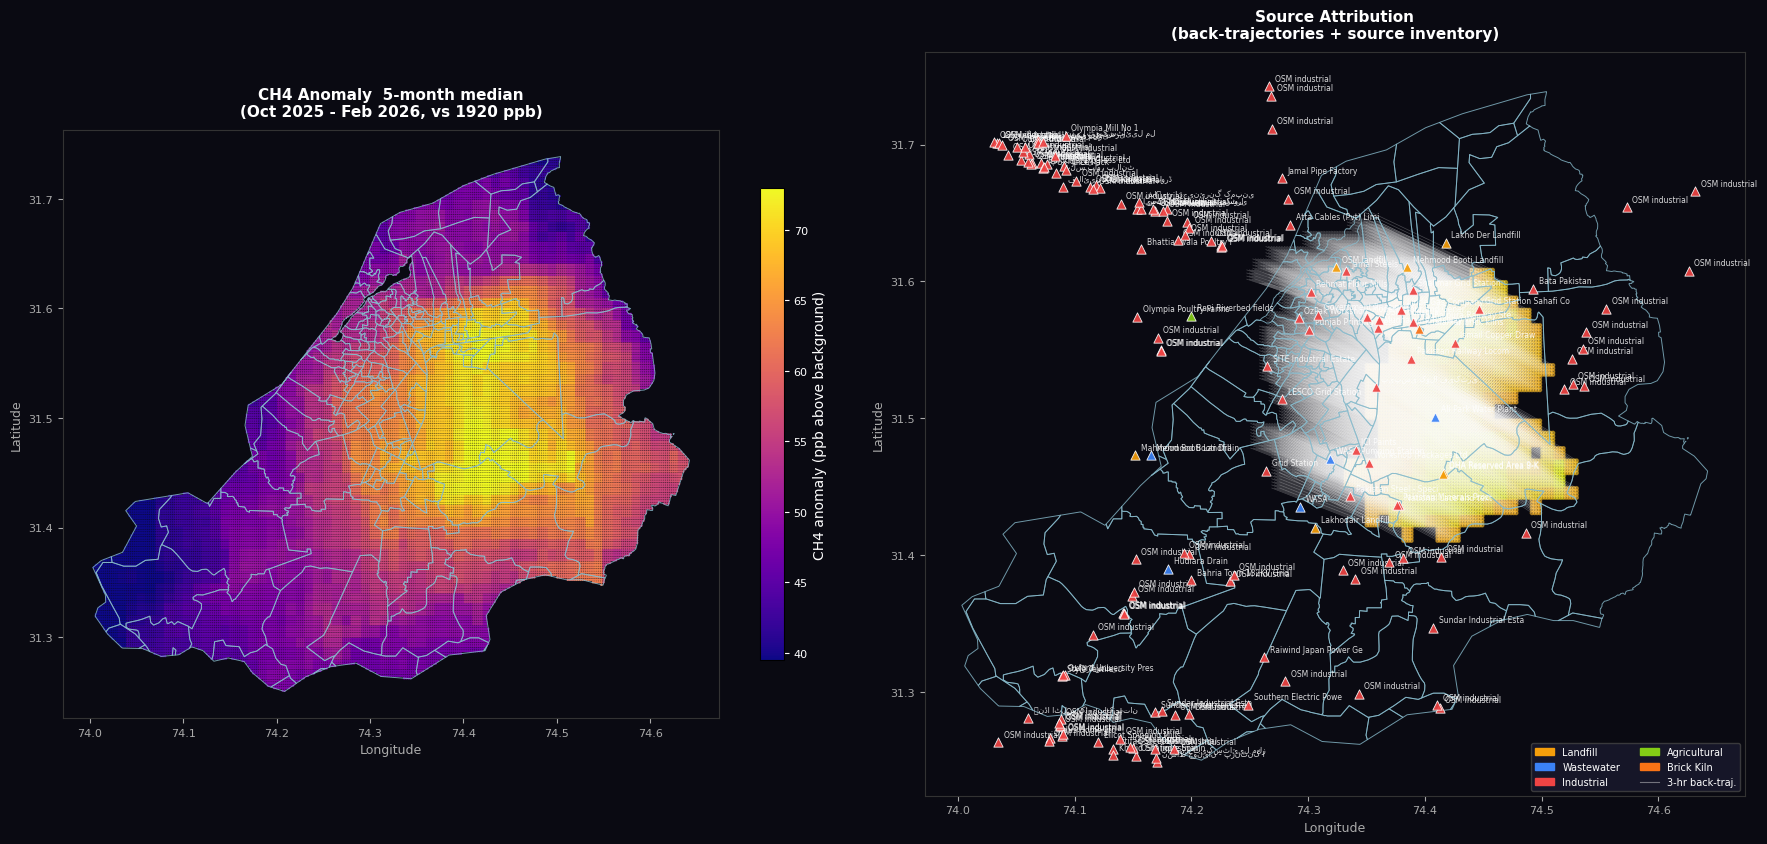

[OK] CH4_source_attribution_map.png


In [13]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

SOURCE_COLORS = {
    "landfill":"#f59e0b","wastewater":"#3b82f6","industrial":"#ef4444",
    "livestock":"#10b981","agricultural":"#84cc16",
    "brick_kiln":"#f97316","emit_plume":"#a855f7",
}

fig, axes = plt.subplots(1, 2, figsize=(18, 9), facecolor="#0a0a12")
for ax in axes: ax.set_facecolor("#0a0a12")

# Left: anomaly choropleth
ax1 = axes[0]
valid = export_grid[export_grid["ch4_anomaly_ppb"].notna()]
valid.plot(column="ch4_anomaly_ppb", cmap="plasma", markersize=0.8, legend=True, ax=ax1,
           vmin=valid["ch4_anomaly_ppb"].quantile(0.02),
           vmax=valid["ch4_anomaly_ppb"].quantile(0.98),
           legend_kwds={"label":"CH4 anomaly (ppb above background)","shrink":0.55})
gdf_boundary.boundary.plot(ax=ax1, color="#88bbcc", linewidth=0.7, alpha=0.8)
cbar = fig.axes[-1]; cbar.tick_params(colors="white",labelsize=8); cbar.yaxis.label.set_color("white")
ax1.set_title(f"CH4 Anomaly  5-month median\n(Oct 2025 - Feb 2026, vs {GLOBAL_BG_PPB:.0f} ppb)",
              color="white", fontsize=11, fontweight="bold", pad=10)
ax1.set_xlabel("Longitude", color="#aaa", fontsize=9)
ax1.set_ylabel("Latitude", color="#aaa", fontsize=9)
ax1.tick_params(colors="#aaa", labelsize=8)
for sp in ax1.spines.values(): sp.set_edgecolor("#333")

# Right: source attribution
ax2 = axes[1]
if len(hotspots_wgs):
    hotspots_wgs.plot(column="ch4_anomaly_ppb", cmap="plasma", markersize=6,
                      alpha=0.5, ax=ax2,
                      vmin=valid["ch4_anomaly_ppb"].quantile(0.02),
                      vmax=valid["ch4_anomaly_ppb"].quantile(0.98))
traj3 = gdf_trajectories[gdf_trajectories["transport_hr"] == 3]
if len(traj3): traj3.plot(ax=ax2, color="#ffffff", linewidth=0.5, alpha=0.25)
for src_type, grp in all_src.groupby("source_type"):
    c = SOURCE_COLORS.get(src_type, "#aaa")
    grp.plot(ax=ax2, color=c, markersize=45, marker="^",
             edgecolors="white", linewidth=0.6, alpha=0.92, zorder=5)
    for _, row in grp.iterrows():
        ax2.annotate(row["name"][:22], xy=(row.geometry.x, row.geometry.y),
                     xytext=(4,4), textcoords="offset points",
                     fontsize=5.5, color="white", alpha=0.85)
gdf_boundary.boundary.plot(ax=ax2, color="#88bbcc", linewidth=0.7, alpha=0.8)
handles = [mpatches.Patch(color=c, label=t.replace("_"," ").title())
           for t, c in SOURCE_COLORS.items() if t in all_src["source_type"].values]
handles.append(mlines.Line2D([],[],color="white",linewidth=0.8,alpha=0.4,label="3-hr back-traj."))
ax2.legend(handles=handles, loc="lower right", fontsize=7,
           facecolor="#1a1a2e", edgecolor="#444", labelcolor="white", ncol=2)
ax2.set_title("Source Attribution\n(back-trajectories + source inventory)",
              color="white", fontsize=11, fontweight="bold", pad=10)
ax2.set_xlabel("Longitude", color="#aaa", fontsize=9)
ax2.set_ylabel("Latitude", color="#aaa", fontsize=9)
ax2.tick_params(colors="#aaa", labelsize=8)
for sp in ax2.spines.values(): sp.set_edgecolor("#333")

plt.tight_layout(pad=1.5)
plt.savefig("CH4_source_attribution_map.png", dpi=180, facecolor="#0a0a12", bbox_inches="tight")
plt.show()
print("[OK] CH4_source_attribution_map.png")